*(cell 1)*

# 22 -- A genome-content RBM: finding hidden features directly from movie content

Notebook 21 tried to explain what e-'s hidden units (e.g. unit 36/53/21 for user 3268) respond to by correlating their already-trained weights against outside fields (year, genre, tag, popularity, genome_scores) -- but that's all *external* correlation, done after the fact with pandas. e- itself never saw any of those fields; its visible layer is only rating-deviation bins.

This notebook does something different: it trains a **new RBM whose visible layer is genome_scores itself** (1128 crowd-sourced tag-relevance scores per movie, from `data/genome_scores.csv`). This RBM's hidden units are then genuinely learned from movie content -- not correlated with it after the fact. We can then check whether any of *this* RBM's hidden units line up with e-'s unit 36/53/21.

*(cell 2)*

### Step 1 -- load genome_scores, build the visible layer (cells 2-3)

`genome_scores.csv` has one row per (movieId, tagId) with a `relevance` in [0, 1]. Pivoted, this is a dense movie x 1128-tag matrix -- 10,239 of the 13,129 movies in `movie_vocab.npy` have genome coverage (78%). Unlike e+/e-'s one-hot rating bins, these are continuous scores, so this RBM uses a **Gaussian visible layer** (standardized to mean 0, std 1 per tag) instead of the softmax/one-hot visible layer e+/e- use.

In [1]:
# cell 3
from pathlib import Path

import numpy as np
import pandas as pd

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent
data_dir = root / "data"
proc = root / "data" / "processed"
out_dir = root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60.0, 60.0)))


movie_vocab = np.load(proc / "movie_vocab.npy").astype(int)

genome_scores = pd.read_csv(data_dir / "genome_scores.csv")
genome_scores = genome_scores[genome_scores["movieId"].isin(set(movie_vocab))]
genome_tags = pd.read_csv(data_dir / "genome_tags.csv").set_index("tagId")["tag"].to_dict()

pivot = genome_scores.pivot(index="movieId", columns="tagId", values="relevance").astype(np.float32)
genome_movie_ids = pivot.index.to_numpy()
tag_ids = pivot.columns.to_numpy()

X_raw = pivot.values
tag_mean, tag_std = X_raw.mean(axis=0), X_raw.std(axis=0) + 1e-8
X = (X_raw - tag_mean) / tag_std

print(f"movies with genome coverage: {len(genome_movie_ids)} / {len(movie_vocab)}")
print(f"visible layer: {X.shape[1]} tags (continuous, standardized)")
print(f"X: mean={X.mean():.4f}  std={X.std():.4f}  (should be ~0, ~1)")

movies with genome coverage: 10239 / 13129
visible layer: 1128 tags (continuous, standardized)
X: mean=-0.0000  std=1.0000  (should be ~0, ~1)


*(cell 4)*

### Step 2 -- train a Gaussian-visible, Bernoulli-hidden RBM with CD-1 (cells 4-5)

Same core CD-1 idea as e+/e- (positive phase, reconstruction, gradient, update) but the visible side is linear (Gaussian mean), not softmax:

$$h\_prob = \sigma(v W + b_h) \qquad v_{recon} = h \, W^T + b_v \qquad \Delta W = \eta\,(v_0^T h\_prob_0 - v_{recon}^T h\_prob_{recon})$$

64 hidden units, LR=0.005, batch=200, 150 epochs (checked to plateau around epoch 100-150 in a standalone test).

epoch 25/150: reconstruction RMSE=0.8105  (0.9s)


epoch 50/150: reconstruction RMSE=0.7825  (1.8s)


epoch 75/150: reconstruction RMSE=0.7727  (2.7s)


epoch 100/150: reconstruction RMSE=0.7677  (3.5s)


epoch 125/150: reconstruction RMSE=0.7650  (4.5s)


epoch 150/150: reconstruction RMSE=0.7632  (5.3s)

final reconstruction RMSE: 0.7632  (standardized units, so 1.0 = no better than predicting the mean)


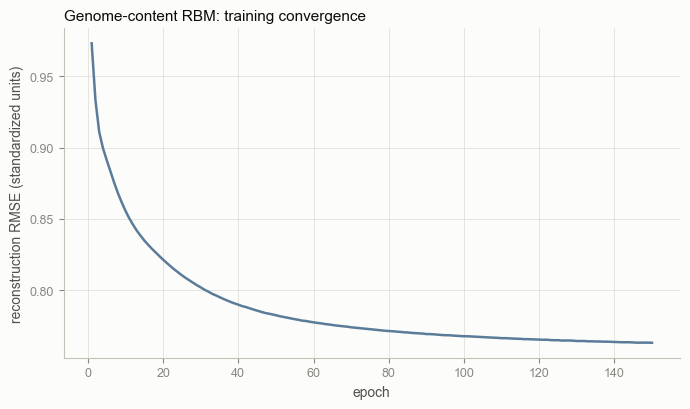

In [2]:
# cell 5
import time

N_HIDDEN_G = 64
LR_G = 0.005
BATCH_G = 200
EPOCHS_G = 150
INIT_SEED_G = 42

n_movies_g, n_tags_g = X.shape
rng_g = np.random.default_rng(INIT_SEED_G)
W_genome = rng_g.normal(0.0, 0.01, size=(n_tags_g, N_HIDDEN_G)).astype(np.float32)
b_v_genome = np.zeros(n_tags_g, dtype=np.float32)
b_h_genome = np.zeros(N_HIDDEN_G, dtype=np.float32)

rmse_history = []
t0 = time.perf_counter()
for epoch in range(EPOCHS_G):
    order = rng_g.permutation(n_movies_g)
    total_sq_err = 0.0
    for start in range(0, n_movies_g, BATCH_G):
        idx = order[start:start + BATCH_G]
        v0 = X[idx]
        bs = v0.shape[0]

        h0_prob = sigmoid(v0 @ W_genome + b_h_genome)
        h0 = (rng_g.random(h0_prob.shape) < h0_prob).astype(np.float32)

        v1 = h0 @ W_genome.T + b_v_genome
        h1_prob = sigmoid(v1 @ W_genome + b_h_genome)

        dW = (v0.T @ h0_prob - v1.T @ h1_prob) / bs
        db_v = (v0 - v1).mean(axis=0)
        db_h = (h0_prob - h1_prob).mean(axis=0)

        W_genome += LR_G * dW
        b_v_genome += LR_G * db_v
        b_h_genome += LR_G * db_h

        total_sq_err += float(((v0 - v1) ** 2).sum())

    rmse_history.append(np.sqrt(total_sq_err / (n_movies_g * n_tags_g)))
    if (epoch + 1) % 25 == 0:
        print(f"epoch {epoch + 1}/{EPOCHS_G}: reconstruction RMSE={rmse_history[-1]:.4f}  ({time.perf_counter() - t0:.1f}s)")

np.save(proc / "rbmGenome_weights.npy", W_genome)
np.save(proc / "rbmGenome_bias_visible.npy", b_v_genome)
np.save(proc / "rbmGenome_bias_hidden.npy", b_h_genome)
print(f"\nfinal reconstruction RMSE: {rmse_history[-1]:.4f}  (standardized units, so 1.0 = no better than predicting the mean)")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

fig, ax = plt.subplots(figsize=(7, 4.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(np.arange(1, EPOCHS_G + 1), rmse_history, color="#5b7c99", linewidth=1.8, zorder=3)
ax.set_xlabel("epoch", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("reconstruction RMSE (standardized units)", color=INK_SECONDARY, fontsize=10)
ax.set_title("Genome-content RBM: training convergence", color=INK_PRIMARY, fontsize=11, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / "genome_rbm_training_curve.png", dpi=150, facecolor=SURFACE)
plt.show()

*(cell 6)*

### Step 3 -- user 3268's e- hidden units vs. this content RBM's hidden units (cells 6-7)

For each of user 3268's rated movies that has genome coverage: get e-'s weight into units 36/53/21 (same quantity as notebook 21 cell 122, `v_ik * W_ikj`, which equals the weight itself since v_ik=1), and this content RBM's `h_prob` for all 64 hidden units. Correlate every content-hidden-unit against every e- unit -- this checks whether a genuinely-trained content model has any hidden unit that lines up, not just a raw genome tag.

In [3]:
# cell 7
W_minus = np.load(proc / "rbmDminus_weights_5k.npy")
channelDminus = np.load(proc / "channelDminus_5k.npy", mmap_mode="r")
mask = np.load(proc / "mask.npy", mmap_mode="r")
cohort_user_ids = np.load(proc / "cohort_user_ids.npy").astype(int)
bin_edges = np.load(proc / "deviation_bin_edges_5k.npy")
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

K = 10
n_movies_vocab = len(movie_vocab)
n_hidden_minus = W_minus.shape[1]
DEMO_USER_ID = 3268
eminus_units = [36, 53, 21]

user_to_row = {int(uid): i for i, uid in enumerate(cohort_user_ids)}
demo_row = user_to_row[DEMO_USER_ID]

v0_m = np.asarray(channelDminus[demo_row]).reshape(-1).astype(np.float64)
v0_m_r = v0_m.reshape(n_movies_vocab, K)
rated_cols_m = np.where(np.asarray(mask[demo_row]) == 1)[0]
W_minus_r = W_minus.reshape(n_movies_vocab, K, n_hidden_minus)

movie_col_to_id = {i: int(mid) for i, mid in enumerate(movie_vocab)}
genome_row_by_movie = {int(mid): i for i, mid in enumerate(genome_movie_ids)}

rows = []
for col in rated_cols_m:
    mid = movie_col_to_id[col]
    if mid not in genome_row_by_movie:
        continue
    k = int(v0_m_r[col].argmax())
    eminus_weights = {f"eminus_{u}": W_minus_r[col, k, u] for u in eminus_units}
    g_row = X[genome_row_by_movie[mid]]
    h_prob_genome = sigmoid(g_row @ W_genome + b_h_genome)
    row = {"movieId": mid, **eminus_weights}
    for h in range(N_HIDDEN_G):
        row[f"content_h{h}"] = h_prob_genome[h]
    rows.append(row)

link_df = pd.DataFrame(rows)
print(f"user {DEMO_USER_ID}: {len(link_df)} / {len(rated_cols_m)} rated movies have genome coverage")

content_cols = [f"content_h{h}" for h in range(N_HIDDEN_G)]
for u in eminus_units:
    corrs = link_df[content_cols].corrwith(link_df[f"eminus_{u}"]).sort_values()
    print(f"\n=== e- unit {u}: top 5 content-RBM hidden units, by |correlation| ===")
    top = pd.concat([corrs.head(3), corrs.tail(3)]).sort_values()
    for name, r in top.items():
        print(f"  {name:14s} r={r:+.4f}")

user 3268: 692 / 696 rated movies have genome coverage

=== e- unit 36: top 5 content-RBM hidden units, by |correlation| ===
  content_h60    r=-0.0937
  content_h43    r=-0.0908
  content_h28    r=-0.0850
  content_h25    r=+0.0968
  content_h55    r=+0.1119
  content_h48    r=+0.1200

=== e- unit 53: top 5 content-RBM hidden units, by |correlation| ===
  content_h30    r=-0.1968
  content_h9     r=-0.1444
  content_h45    r=-0.1373
  content_h47    r=+0.1370
  content_h8     r=+0.1406
  content_h16    r=+0.1919

=== e- unit 21: top 5 content-RBM hidden units, by |correlation| ===
  content_h17    r=-0.1684
  content_h33    r=-0.1378
  content_h30    r=-0.1191
  content_h41    r=+0.1064
  content_h53    r=+0.1065
  content_h8     r=+0.1804


*(cell 8)*

##### Chart: best-matching content-RBM hidden unit per e- unit

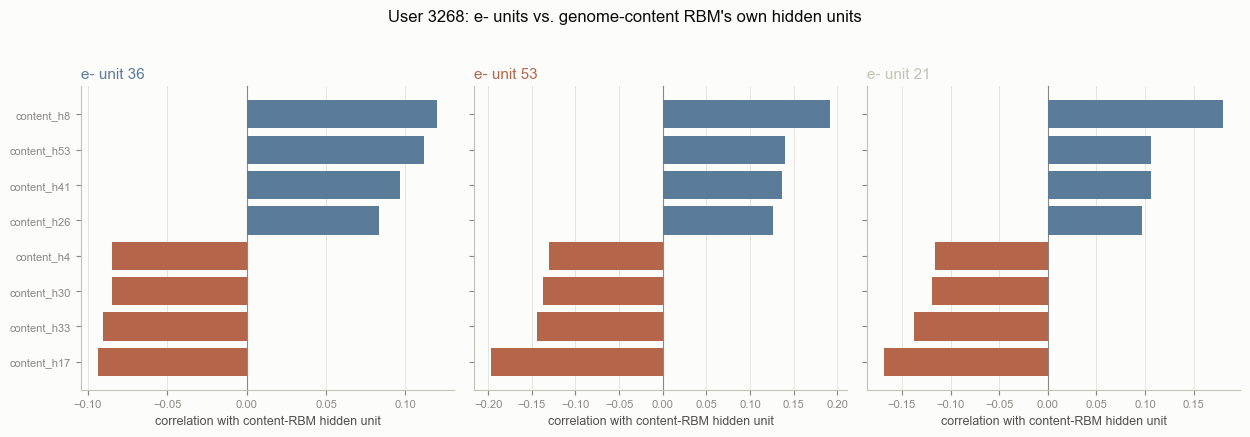

In [4]:
# cell 9
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

palette = {36: "#5b7c99", 53: "#b4654a", 21: "#c3c2b7"}

fig, axes = plt.subplots(1, len(eminus_units), figsize=(4.2 * len(eminus_units), 4.2), facecolor=SURFACE, sharey=True)
for ax, u in zip(axes, eminus_units):
    corrs = link_df[content_cols].corrwith(link_df[f"eminus_{u}"]).sort_values()
    top = pd.concat([corrs.head(4), corrs.tail(4)])
    ax.set_facecolor(SURFACE)
    colors = ["#b4654a" if v < 0 else "#5b7c99" for v in top.values]
    ax.barh(range(len(top)), top.values, color=colors, zorder=3)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=8)
    ax.axvline(0, color=INK_MUTED, linewidth=0.8, zorder=2)
    ax.set_title(f"e- unit {u}", color=palette[u], fontsize=11, loc="left")
    ax.set_xlabel("correlation with content-RBM hidden unit", color=INK_SECONDARY, fontsize=9)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    ax.grid(axis="x", color=GRID, linewidth=0.6, zorder=0)

fig.suptitle(f"User {DEMO_USER_ID}: e- units vs. genome-content RBM's own hidden units", fontsize=12, color=INK_PRIMARY, y=1.03)
plt.tight_layout()
plt.savefig(out_dir / "genome_rbm_vs_eminus_correlation.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()